In [ ]:
# ======================================================
# Notebook 10: Statistical Quality Control & Feature Filtering
#
# Goal:
# Improve statistical robustness by identifying and
# removing noisy communication features before
# downstream network analysis and XAI.
# ======================================================


In [5]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

print(communication_matrix.shape)
communication_matrix.head()

(138, 3489)


,LGALS9→PTPRC,LGALS9→MET,LGALS9→CD44,LGALS9→LRP1,LGALS9→CD47,LGALS9→PTPRK,LGALS9→COLEC12,LGALS9→HAVCR2,LGALS9→MRC2,DLL1→NOTCH1,...,BMP6→AMHR2,GDF11→ACTR2,GDF1→ACTR2,INHBA→ACTR2,BMP7→ACTR2,BMP2→ACTR2,BMP15→ACTR2,CSF1→CSF3R,IL36G→IFNAR1,IL36G→IFNAR2
wu_natgen_CID3586,8.633867,1.044805,8.393451,0.776248,3.758318,1.168318,0.296762,3.943516,0.637201,0.292995,...,0.000000e+00,0.546232,0.0,1.127656,0.008232,0.995683,0.0,0.114970,0.000000,0.000000
wu_natgen_CID3921,7.129786,0.670546,9.661072,2.296553,5.089897,1.524040,0.145497,2.765677,0.596229,0.356648,...,0.000000e+00,0.241065,0.0,2.798962,0.346355,0.568526,0.0,0.149420,0.000000,0.000000
wu_natgen_CID45171,8.077541,0.145614,7.158105,0.689071,4.376402,1.669631,0.300532,0.799553,0.391112,0.017953,...,0.000000e+00,2.182149,0.0,0.993794,0.057089,0.080615,0.0,0.032563,0.000000,0.000000
wu_natgen_CID3838,16.582199,2.095036,17.671549,3.576852,10.819265,2.728356,1.450304,5.477222,2.551522,2.010751,...,5.337549e-06,7.685503,0.0,7.648826,0.520871,3.494657,0.0,0.315217,0.003883,0.003169
wu_natgen_CID4066,6.538203,0.480212,4.661026,1.018777,4.621882,1.056085,0.198088,1.693815,0.611983,0.456659,...,6.623769e-07,0.439607,0.0,1.183399,0.088907,0.741925,0.0,0.104455,0.000000,0.000000


In [6]:
print("Patients :", communication_matrix.shape[0])
print("Features :", communication_matrix.shape[1])

print("\nMissing values:")
print(communication_matrix.isna().sum().sum())

zero_fraction = (communication_matrix == 0).mean().mean()

print(f"\nOverall sparsity: {zero_fraction:.3f}")

Patients : 138
Features : 3489

Missing values:
0

Overall sparsity: 0.377


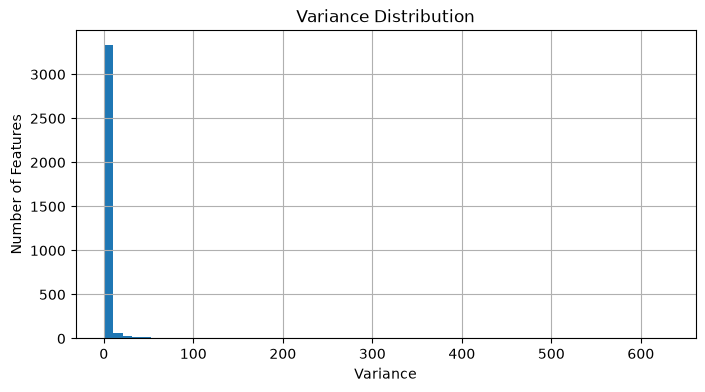

count    3489.000000
mean        2.744499
std        20.378662
min         0.000000
25%         0.000048
50%         0.007165
75%         0.323429
max       629.703092
dtype: float64

In [7]:
feature_variance = communication_matrix.var(axis=0)

plt.figure(figsize=(8,4))
feature_variance.hist(bins=60)

plt.xlabel("Variance")
plt.ylabel("Number of Features")
plt.title("Variance Distribution")
plt.show()

feature_variance.describe()

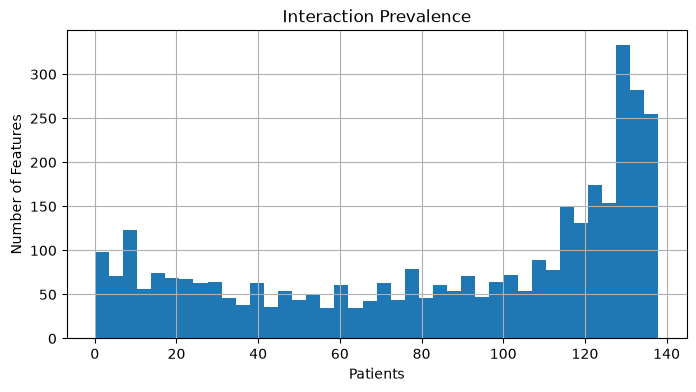

count    3489.000000
mean       85.905990
std        45.275992
min         0.000000
25%        45.000000
50%       102.000000
75%       127.000000
max       138.000000
dtype: float64

In [8]:
presence = (communication_matrix > 0).sum(axis=0)

plt.figure(figsize=(8,4))
presence.hist(bins=40)

plt.xlabel("Patients")
plt.ylabel("Number of Features")
plt.title("Interaction Prevalence")
plt.show()

presence.describe()

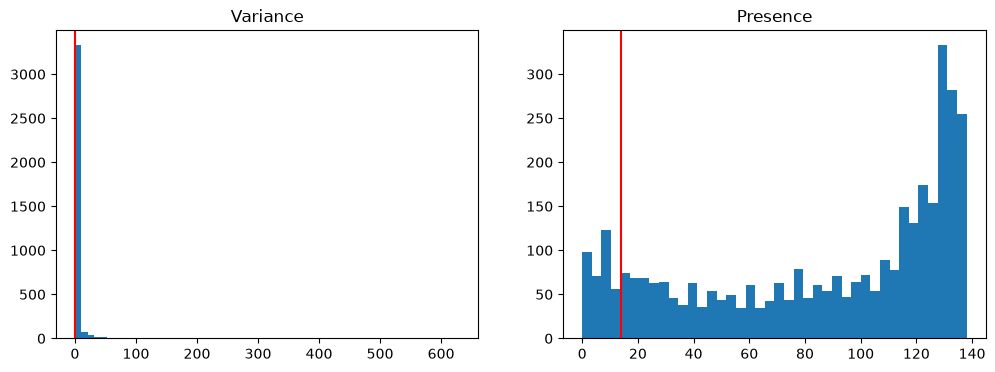

10% variance threshold : 1.142289770975069e-07
10% presence threshold : 14.0


In [9]:
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].hist(feature_variance, bins=60)
ax[0].axvline(feature_variance.quantile(0.10), color="red")
ax[0].set_title("Variance")

ax[1].hist(presence, bins=40)
ax[1].axvline(presence.quantile(0.10), color="red")
ax[1].set_title("Presence")

plt.show()

print("10% variance threshold :", feature_variance.quantile(0.10))
print("10% presence threshold :", presence.quantile(0.10))

In [10]:
variance_threshold = feature_variance.quantile(0.10)
presence_threshold = presence.quantile(0.10)

filtered_matrix = communication_matrix.loc[
    :,
    (feature_variance > variance_threshold) &
    (presence > presence_threshold)
]

print("Original:", communication_matrix.shape)
print("Filtered:", filtered_matrix.shape)

Original: (138, 3489)
Filtered: (138, 3004)


In [11]:
print("Original sparsity:")
print((communication_matrix == 0).mean().mean())

print("\nFiltered sparsity:")
print((filtered_matrix == 0).mean().mean())

print("\nRemoved features:")
print(
    communication_matrix.shape[1] -
    filtered_matrix.shape[1]
)

Original sparsity:
0.377492824238497

Filtered sparsity:
0.29120351608483375

Removed features:
485


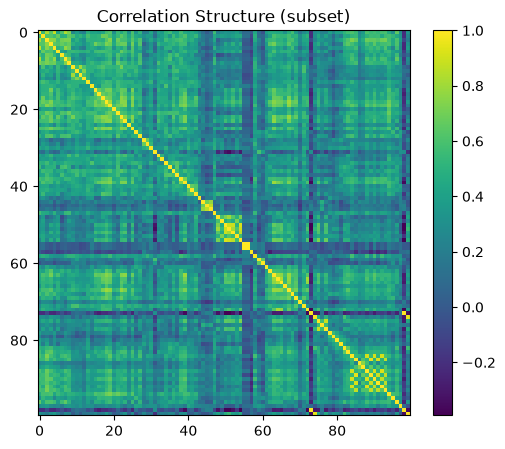

In [12]:
corr = filtered_matrix.corr(method="spearman")

plt.figure(figsize=(6,5))

plt.imshow(corr.iloc[:100,:100], aspect="auto")
plt.colorbar()

plt.title("Correlation Structure (subset)")
plt.show()

In [13]:
filtered_matrix.to_csv(
    "data/outputs/filtered_communication_matrix.csv"
)

print("Saved.")

print(filtered_matrix.shape)

Saved.
(138, 3004)
